In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

df = pd.read_csv('../data/apples_and_oranges.csv')

df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [73]:
x = df[['Weight', 'Size']]
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [78]:
y_pred = model.predict(x_test)
print(f"Klasifikasi Report : {classification_report(y_test, y_pred)}")
print(f"Akurasi : {accuracy_score(y_test, y_pred) * 100} %")

Klasifikasi Report :               precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Akurasi : 100.0 %


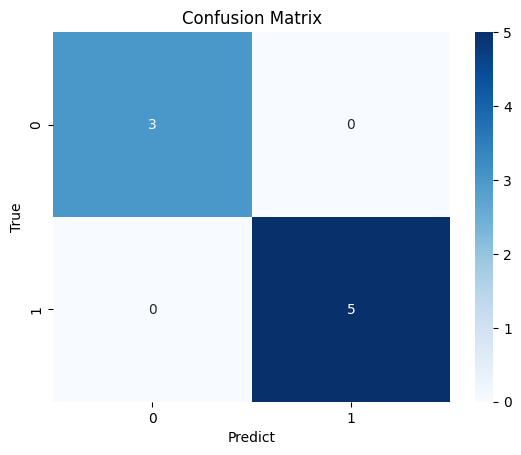

In [80]:
cm  = confusion_matrix(y_test, y_pred)
plt.Figure(figsize=(8,6))
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

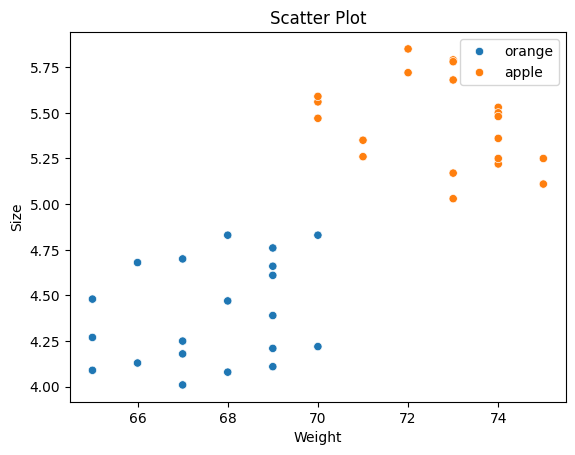

In [87]:
plt.Figure(figsize=(8,6))
sns.scatterplot(data=df, x='Weight', y='Size', hue='Class')
plt.title("Scatter Plot")
plt.legend()
plt.show()

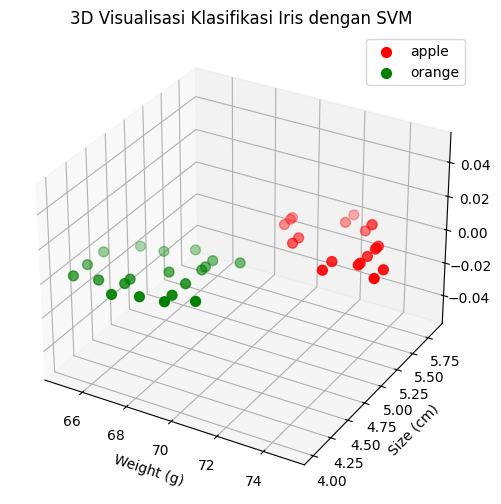

In [113]:
if 'Classes_encode' in df.columns:
    enc_col = 'Classes_encode'
else:
    # hanya buat encoder baru jika memang belum ada
    le = LabelEncoder()
    df['Classes_encode'] = le.fit_transform(df['Class'])
    enc_col = 'Classes_encode'

labels = le.classes_
colors = ['r', 'g', 'b']

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, classes in enumerate(labels):
    subset = df[df[enc_col] == i]
    ax.scatter(
        subset['Weight'],
        subset['Size'],
        color=colors[i],
        label=classes,
        s=50
    )

ax.set_xlabel('Weight (g)')
ax.set_ylabel('Size (cm)')
ax.set_title('3D Visualisasi Klasifikasi Iris dengan SVM')
ax.legend()
plt.show()